In [1]:
import sys 
sys.path.append('C:/Users/DATA/Documents/datos/01_script/inicio/funciones')
from funciones import *
from funciones_spark import *
from variables_inicio import *
from utils_sql import *

spark = SparkSession.builder \
    .appName("SparkExample") \
    .master("local[*]") \
    .config('spark.driver.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.memory', '8g') \
    .config('spark.driver.memory', '8g') \
    .getOrCreate()

filename='TARGET_202606_02.csv'
df_prueba=cargar_archivo_csv(spark,filename,';',True)
print(df_prueba.columns)

['ID PROVEEDOR', 'NOMBRES', 'APELLIDO PATERNO', 'APELLIDO MATERNO', 'TIPO DE DOCUMENTO', 'NUMERO_DOCUMENTO', 'TASA(TEA)', 'TEA_DF', 'TELEFONO_CASA1', 'TELEFONO_CASA2', 'TELEFONO_CASA3', 'TELEFONO_CASA4', 'TELEFONO_CASA5', 'TELEFONO_CASA6', 'TELEFONO_CASA7', 'TELEFONO_CASA8', 'TELEFONO_CASA9', 'TELEFONO_CASA10', 'NUEVO_GRUPO03', 'PROB_CONTACTO', 'DINERS_NRO1', 'DINERS_NRO2', 'DINERS_NRO3', 'DINERS_NRO4', 'DINERS_NRO5', 'OSIPTEL_NRO1_ENCRIP', 'OSIPTEL_NRO2_ENCRIP', 'OSIPTEL_NRO3_ENCRIP', 'OSIPTEL_NRO4_ENCRIP', 'OSIPTEL_NRO5_ENCRIP', 'DCP01', 'DCP02', 'DCP03', 'DCP04', 'DCP05', 'CELULAR01', 'CELULAR02', 'CELULAR03', 'CELULAR04', 'CELULAR05', 'CELULAR06', 'CELULAR07', 'CELULAR08', 'CELULAR09', 'CELULAR10', 'RECENCIA', 'PERFIL', 'PRODUCTO', 'LINEA_DIN', 'ID RESULTADO GESTION', 'TCEA_NEW', 'TCEA_CUOTAS_DF', 'LIMACALLAO', 'FECHA_NACIMIENTO', 'PROVINCIA', 'L_BCP', 'L_BBVA', 'L_IBK', 'L_SCO', 'L_BIF', 'L_CITI', 'L_FIN', 'L_RIP', 'L_CMR', 'L_CRESCO', 'L_CEN', 'L_AZT', 'L_UNO', 'L_GNB', 'L_EFE', 

In [3]:
query = f"""
    SELECT  *
  FROM DANTALION.[dbo].Base_Maestra_Diners_TC
  where FECHA_ENVIO>='2026-06-01'
  and NUMERO_DOCUMENTO is not null
    """
df_formato=obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)

In [4]:
df_prueba = df_prueba.withColumn(
    "NUMERO_DOCUMENTO",
    F.right(
        F.concat(F.lit("00000000"), F.col("NUMERO_DOCUMENTO")),
        F.lit(8)
    )

)


In [5]:
exprs = [
    F.count(F.when(F.col(c).isNotNull(), c)).alias(c)
    for c in df_prueba.columns
]

df_counts = df_prueba.agg(*exprs).collect()[0].asDict()

cols_con_data = [c for c, v in df_counts.items() if v > 0]

df_prueba = df_prueba.select(cols_con_data)



In [ ]:
# query = f"""
#     SELECT*
#     FROM [DANTALION].[dbo].[Base_Maestra_Diners_TC]
#     where FECHA_ENVIO>='2026-05-01'
#     and    FECHA_ENVIO <'2026-05-20'
#     """
# df_formato=obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)

In [6]:
df_prueba=df_prueba.withColumnRenamed('LINEA_DIN','LINEA CREDITO DOLARES')
df_prueba=df_prueba.withColumnRenamed('CELULAR01','CELULAR1')
df_prueba=df_prueba.withColumnRenamed('CELULAR02','CELULAR2')
df_prueba=df_prueba.withColumnRenamed('CELULAR03','CELULAR3')
df_prueba=df_prueba.withColumnRenamed('CELULAR04','CELULAR4')
df_prueba=df_prueba.withColumnRenamed('CELULAR05','CELULAR5')
df_prueba=df_prueba.withColumnRenamed('CELULAR06','CELULAR6')
df_prueba=df_prueba.withColumnRenamed('RECENCIA','RECURRENCIA')
df_prueba=df_prueba.withColumnRenamed('FECHA_NACIMIENTO','FEC_NAC')
df_prueba=df_prueba.withColumnRenamed('TCEA_NEW','TCEA')
df_prueba=df_prueba.withColumnRenamed('NUEVO_GRUPO03','PROB_CONTACTO')

df_prueba=df_prueba.withColumn('AÑO_DURACION_BASE',F.lit('2026'))
df_prueba=df_prueba.withColumn('MES_DURACION_BASE',F.lit('06'))
df_prueba=df_prueba.withColumn('FECHA_ENVIO',F.lit('2026-06-09'))
df_prueba=df_prueba.withColumn('SERVICIO',F.lit('02'))



cols_prueba = set(df_prueba.columns)
cols_formato = set(df_formato.columns)

solo_en_prueba = cols_prueba - cols_formato
print("Solo falta estas columnas en tc:", solo_en_prueba)

Solo falta estas columnas en tc: {'EX_SOCIO', 'LIMACALLAO'}


In [11]:

df_prueba = df_prueba.withColumn(
    "CEL01",
    F.when(F.col("CELULAR1").rlike(r"^9\d{0,8}$"), F.col("CELULAR1"))
)
df_prueba = df_prueba.withColumn(
    "CEL02",
    F.when(F.col("CELULAR2").rlike(r"^9\d{0,8}$"), F.col("CELULAR2"))
)

df_prueba = df_prueba.withColumn(
    "LIMAPROVINCIA",
    F.when(F.col("PROVINCIA")=='LIMA', F.lit("LIMA"))
    .otherwise(F.lit('PROVINCIA'))
)

In [18]:
df_prueba=df_prueba.drop('ULT_TASA_EX_SOCIO', 'LINEA_ANT_EX_SOCIO', 'EX_SOCIO', 'LIMACALLAO')


In [38]:
df_prueba=df_prueba.filter(F.col('NUMERO_DOCUMENTO').isNotNull())

In [12]:
df_prueba.join(df_formato,['NUMERO_DOCUMENTO'],'inner').count()

0

In [14]:
df_prueba.dropDuplicates(['NUMERO_DOCUMENTO']).count()

553

In [16]:
df_prueba=df_prueba.filter(F.col('NUMERO_DOCUMENTO').isNotNull())

In [17]:
df_prueba.count()

552

In [19]:
df_prueba.show(10,truncate=False)

+------------+---------+----------------+-----------------+----------------+---------+-------+-------------+---------+--------+-----------+---------+--------+---------------------+--------------------+-----+--------------+----------+----------+-----+------+-----+-----+-----+------+-----+-----+-----+--------+-----+-----+-----+-----+-----+-----+-----+-----------------+-----------------+-----------+--------+---------+-----+-------------+
|ID PROVEEDOR|NOMBRES  |APELLIDO PATERNO|TIPO DE DOCUMENTO|NUMERO_DOCUMENTO|TASA(TEA)|TEA_DF |PROB_CONTACTO|CELULAR1 |CELULAR2|RECURRENCIA|PERFIL   |PRODUCTO|LINEA CREDITO DOLARES|ID RESULTADO GESTION|TCEA |TCEA_CUOTAS_DF|FEC_NAC   |PROVINCIA |L_BCP|L_BBVA|L_IBK|L_SCO|L_BIF|L_CITI|L_FIN|L_RIP|L_CMR|L_CRESCO|L_CEN|L_AZT|L_UNO|L_GNB|L_EFE|L_COM|L_NAC|AÑO_DURACION_BASE|MES_DURACION_BASE|FECHA_ENVIO|SERVICIO|CEL01    |CEL02|LIMAPROVINCIA|
+------------+---------+----------------+-----------------+----------------+---------+-------+-------------+---------+----

In [20]:
append_table_SQL(spark,df_prueba,f'Base_Maestra_Diners_TC',server_kishin,user_kishin,pwd_kishin,'DANTALION')


In [2]:
# append_table_SQL(spark,df_prueba_plus,f'asdasdasdasdasd_borrar',server_kishin,user_kishin,pwd_kishin,'DANTALION')


In [13]:
df_prueba_plus.filter(F.col('NumDoc').isNull()).count()

0

In [11]:
print(df_prueba.dropDuplicates(['NumDoc']).count())
print(df_prueba_plus.dropDuplicates(['NumDoc']).count())
print(df_prueba_plus.count())
print(df_prueba.count())


4556
228
228
4556


In [ ]:
# df_prueba = df_prueba.withColumn(
#     'Nombre_Largo',
#     F.concat_ws(
#         ' ',
#         F.when(
#             F.trim(F.col('ApPaterno')) != '',
#             F.trim(F.col('ApPaterno'))
#         ),
#         F.when(
#             F.trim(F.col('ApMaterno')) != '',
#             F.trim(F.col('ApMaterno'))
#         ),
#         F.when(
#             F.trim(F.col('Nombre')) != '',
#             F.trim(F.col('Nombre'))
#         )
#     )
# )

# df_prueba_plus = df_prueba_plus.withColumn(
#     'Nombre_Largo',
#     F.concat_ws(
#         ' ',
#         F.when(
#             F.trim(F.col('ApPaterno')) != '',
#             F.trim(F.col('ApPaterno'))
#         ),
#         F.when(
#             F.trim(F.col('ApMaterno')) != '',
#             F.trim(F.col('ApMaterno'))
#         ),
#         F.when(
#             F.trim(F.col('Nombre')) != '',
#             F.trim(F.col('Nombre'))
#         )
#     )
# )

In [28]:
print([row['TEA_FORMATO' ] for row in df_prueba.select('TEA_FORMATO').distinct().collect()])
print([row['TEM_FORMATO' ] for row in df_prueba.select('TEM_FORMATO').distinct().collect()])
print([row['TASA_APP' ] for row in df_prueba.select('TASA_APP').distinct().collect()])

print([row['TEA_FORMATO' ] for row in df_prueba_plus.select('TEA_FORMATO').distinct().collect()])
print([row['TEM_FORMATO' ] for row in df_prueba_plus.select('TEM_FORMATO').distinct().collect()])
print([row['TASA_APP' ] for row in df_prueba_plus.select('TASA_APP').distinct().collect()])


['22.56', '34.96', '15.53', '14.03', '16.49', '29.99', '18.44', '41.41', '12.55', '28.44', '44.2', '27.72', '11.49', '20.98', '32.5', '25.34', '35.99', '17.04']
['2.20', '0.99', '1.28', '0.90', '1.71', '2.06', '2.59', '1.32', '2.53', '2.93', '0.91', '1.21', '2.11', '1.90', '1.42', '3.10', '1.10', '1.59', '2.37', '1.60']
['10.34', '22.56', '34.96', '15.53', '14.03', '16.49', '18.44', '37.5', '12.55', '28.44', '9.9', '27.72', '11.49', '20.98', '25.34', '35.99', '32.5', '17.04']
['22.56', '15.53', '34.96', '14.03', '16.49', '18.44', '41.41', '12.55', '28.44', '27.72', '11.49', '20.98', '32.5', '25.34', '17.04']
['0.99', '1.28', '0.90', '1.71', '2.06', '1.32', '2.53', '2.93', '0.91', '1.21', '2.11', '1.90', '1.42', '1.10', '1.59', '2.37', '1.60']
['10.34', '22.56', '15.53', '14.03', '16.49', '18.44', '12.55', '28.44', '9.9', '27.72', '11.49', '20.98', '25.34', '17.04', None]


In [ ]:
print([row['Nombre_Largo' ] for row in df_prueba_plus.select('Nombre_Largo').distinct().collect()])


['ROJAS LEGUIA MANUEL CARLOS', 'GONZALES MACEDA JACKLIN DEL ROCIO', 'KANEGUSUKU AQUINO KAORI NAOMI', 'CEVALLOS VELASCO CLAUDIA ', 'LOPEZ DEL AGUILA JORGE LUIS', 'CARRASCO VALENZUELA KARINA ', 'HOYOS HEINZLE MARIA DE LOURDES ETELVINA', 'VIDAL MARQUEZ ARENA ', 'ULLOA MENDOZA ALEJANDRINA STEPHANIE', 'BURBANO GAMERO TLIFANY TULIA', 'SIERRA VERA ROCIO TEODOLINDA', 'TAGLE PACHERREZ ROXANA JULIA', 'PEREZ YANAYACO GLORIA MARIBEL', 'CEVALLOS HAMILTON GUILLERMO ALBERTO', 'MEJIA CABALLERO JUAN EDUARDO', 'MENDOZA HUERTA LUIS ENRIQUE', 'MALUQUISH SILVA VIDELMO ', 'PASTOR VILLASECA EDUARDO ARTURO', 'VILLANUEVA NEHMAD JAVIER ', 'ROJAS RAMOS LEONARDO MAURICIO', 'AREVALO SANCHEZ ROLANDO ', 'STUART TERRONES CARLA PATRICIA', 'GALVEZ OLGUIN JANET MERCEDES', 'ARAUJO GOMERO ELVIS ARTURO', 'PERALTA CASANOVA HERNAN AUGUSTO', 'CHUNGA ESTRADA JORGE EMILIO', 'FUERTES OPORTO ROSA LUZ', 'VALVERDE AVILA JESSICA LOURDES', 'VIDAL SALCEDO DERICK SANTIAGO', 'CALLE URTEAGA LUCIANA BEATRIZ', 'COLONE AMEZ FRANCO ', 'GONZA

In [ ]:
df_prueba_plus.show(10,truncate=False)

+--------------+--------+----------+---------------+-----------+--------------+-----------+-----------+------------+-----------------+---------+-----------------+----------------+---------------+-----------+----------------+---------+----+------------------------------+---------+---------+---------+-----+---------------+------------+------------------------------------------------------------+------------------------------------------------------------+------------------------+-------------------------+----------------------------+------------------------------------------------------+-----------------+---------+------------+------------------------------+-----------+-----------------------+--------------------------------------------+---------------------------------------------------+-----------------+-------------+----------------+------------+-----------+------------------+------------+------------+----------+----------+------------+----------+----------+------------+----------+---

In [5]:
overwrite_table_SQL(spark,df_prueba,f'asuu_borrar_de_nuevo_ppdplus_diners',server_kishin,user_kishin,pwd_kishin,'DANTALION')

# append_table_SQL(spark,df_prueba,f'asuu_borrar_de_nuevo_tc_diners',server_kishin,user_kishin,pwd_kishin,'DANTALION')

# filename='20260501_BD_ECR_TARGET.csv'
# df_prueba_sar=cargar_archivo_csv(spark,filename,';',True)

In [6]:
spark.stop()

In [24]:
query = f"""
    SELECT * FROM CRONOX.DBO.AQUI
    """
df_formato=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)
print(df_formato.columns)

['Dni_cliente', 'NOMBRE', 'fecha_visita', 'OFERTA_CREDICASH', 'OFERTA_ELECTRO']


In [6]:
print(df_prueba.columns)

['numdoc', 'tipo_campaña_ppd']


In [ ]:
filename='TARGET_202605_02.csv'
df_prueba=cargar_archivo_csv(spark,filename,';',True)
print(df_prueba.columns)

# filename='20260501_BD_ECR_TARGET.csv'
# df_prueba_sar=cargar_archivo_csv(spark,filename,';',True)

['ID PROVEEDOR', 'NOMBRES', 'APELLIDO PATERNO', 'APELLIDO MATERNO', 'TIPO DE DOCUMENTO', 'NUMERO_DOCUMENTO', 'TASA(TEA)', 'TEA_DF', 'TELEFONO_CASA1', 'TELEFONO_CASA2', 'TELEFONO_CASA3', 'TELEFONO_CASA4', 'TELEFONO_CASA5', 'TELEFONO_CASA6', 'TELEFONO_CASA7', 'TELEFONO_CASA8', 'TELEFONO_CASA9', 'TELEFONO_CASA10', 'NUEVO_GRUPO03', 'PROB_CONTACTO', 'DINERS_NRO1', 'DINERS_NRO2', 'DINERS_NRO3', 'DINERS_NRO4', 'DINERS_NRO5', 'OSIPTEL_NRO1_ENCRIP', 'OSIPTEL_NRO2_ENCRIP', 'OSIPTEL_NRO3_ENCRIP', 'OSIPTEL_NRO4_ENCRIP', 'OSIPTEL_NRO5_ENCRIP', 'DCP01', 'DCP02', 'DCP03', 'DCP04', 'DCP05', 'CELULAR01', 'CELULAR02', 'CELULAR03', 'CELULAR04', 'CELULAR05', 'CELULAR06', 'CELULAR07', 'CELULAR08', 'CELULAR09', 'CELULAR10', 'RECENCIA', 'PERFIL', 'PRODUCTO', 'LINEA_DIN', 'ID RESULTADO GESTION', 'TCEA_NEW', 'TCEA_CUOTAS_DF', 'LIMACALLAO', 'FECHA_NACIMIENTO', 'PROVINCIA', 'L_BCP', 'L_BBVA', 'L_IBK', 'L_SCO', 'L_BIF', 'L_CITI', 'L_FIN', 'L_RIP', 'L_CMR', 'L_CRESCO', 'L_CEN', 'L_AZT', 'L_UNO', 'L_GNB', 'L_EFE', 

In [ ]:
['ID PROVEEDOR', 'NOMBRES', 'APELLIDO PATERNO', 'APELLIDO MATERNO', 'TIPO DE DOCUMENTO', 'NUMERO_DOCUMENTO', 'TASA(TEA)', 'TEA_DF', 'TELEFONO_CASA1', 'TELEFONO_CASA2', 'TELEFONO_CASA3', 'TELEFONO_CASA4', 'TELEFONO_CASA5', 'TELEFONO_CASA6', 'TELEFONO_CASA7', 'TELEFONO_CASA8', 'TELEFONO_CASA9', 'TELEFONO_CASA10', 'NUEVO_GRUPO03', 'PROB_CONTACTO', 'DINERS_NRO1', 'DINERS_NRO2', 'DINERS_NRO3', 'DINERS_NRO4', 'DINERS_NRO5', 'OSIPTEL_NRO1_ENCRIP', 'OSIPTEL_NRO2_ENCRIP', 'OSIPTEL_NRO3_ENCRIP', 'OSIPTEL_NRO4_ENCRIP', 'OSIPTEL_NRO5_ENCRIP', 'DCP01', 'DCP02', 'DCP03', 'DCP04', 'DCP05', 'CELULAR01', 'CELULAR02', 'CELULAR03', 'CELULAR04', 'CELULAR05', 'CELULAR06', 'CELULAR07', 'CELULAR08', 'CELULAR09', 'CELULAR10', 'RECENCIA', 'PERFIL', 'PRODUCTO', 'LINEA_DIN', 'ID RESULTADO GESTION', 'TCEA_NEW', 'TCEA_CUOTAS_DF', 'LIMACALLAO', 'FECHA_NACIMIENTO', 'PROVINCIA', 'L_BCP', 'L_BBVA', 'L_IBK', 'L_SCO', 'L_BIF', 'L_CITI', 'L_FIN', 'L_RIP', 'L_CMR', 'L_CRESCO', 'L_CEN', 'L_AZT', 'L_UNO', 'L_GNB', 'L_EFE', 'L_COM', 'L_NAC', 'EX_SOCIO', 'LINEA_ANT_EX_SOCIO', 'ULT_TASA_EX_SOCIO', 'Fuente']

['CANAL', 'ELECCION', 'NUM_CTA', 'NUM_CTA_LP', 'TIPDOC', 'CODDOC', ' LINEA_SAE ', 'PCT_SAE', 'TEA', 'SEGMENTO', 'CLIENTE_DESDE', 'NOMBRE_1', 'NOMBRE_2', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'CELULAR', 'TELF_DOM', 'TELF_OFI', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'DIRECCION', 'FEC_NAC', 'EDAD', 'RNG_LINEA_MAX_TC', 'RNG_SUMA_LINEA_TC', 'RNG_SALDO_CONSUMO', 'RNG_EDAD', 'RNG_SALDO_TC', 'RNG_INGRESO', 'RNG_SALDO_TC_ENTRE_INGRESO', 'RNG_LINEA_TCENCO', 'RNG_LINEA_TCENCO_ENTRE_LINEA_MAX', 'RNG_SALDO_CONSUMO_ENTRE_INGRESO', ' RNG_SALDO_TC_ENTRE_LINEA_TOTAL_TC ', ' REGIMEN_LABORAL ', 'FEC_FACT', 'FLG_AUT_DATOS', 'FLG_MEJORA', 'FLG_PAGO_DIFERIDO', '_c40']


In [4]:
df_prueba = df_prueba.withColumn(
    "NUMERO_DOCUMENTO",
    F.right(
        F.concat(F.lit("00000000"), F.col("NUMERO_DOCUMENTO")),
        F.lit(8)
    )
)


# df_prueba = df_prueba.withColumn(
#     "CODDOC",
#     F.right(
#         F.concat(F.lit("00000000"), F.col("CODDOC")),
#         F.lit(8)
#     )
# )
# df_prueba_ppdplus = df_prueba_ppdplus.withColumn(
#     "DNI",
#     F.right(
#         F.concat(F.lit("00000000"), F.col("DNI")),
#         F.lit(8)
#     )
# )

In [9]:
df_prueba_sar.filter(F.col('CODDOC').isNull()).count()

0

In [5]:
df_base=since_base_maestra_efe_negocio(spark)

In [9]:
df_prueba=df_prueba.join(df_base,['vendor_lead_code'],'inner')

In [8]:
df_prueba.count()

6288

In [10]:
df_list_filtrada = df_prueba.select(
    'vendor_lead_code', 'TELEFONO', 'title', 'first_name',
    'last_name', 'address1', 'address2', 'address3',
    'city', 'province', 'email', 'security_phrase', 'comments'
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'efe.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [ ]:

ruta_archivo = os.path.join(ruta_csv, 'ultimo.xlsx')
df_export.to_excel(ruta_archivo, index=False)

In [ ]:
Inventario_30042026.xlsx

In [29]:
cols_prueba = set(df_prueba.columns)
cols_formato = set(df_formato.columns)

solo_en_prueba = cols_prueba - cols_formato
print("Solo en df_prueba:", solo_en_prueba)

Solo en df_prueba: {'ULT_TASA_EX_SOCIO', 'LIMACALLAO', 'LINEA_ANT_EX_SOCIO', 'EX_SOCIO', 'CELULAR3'}


In [30]:
solo_en_formato = cols_formato - cols_prueba
print("Solo en df_formato:", solo_en_formato)

Solo en df_formato: {'FLAT3', 'REP1', 'BENCH_DINERS', 'FLAT2', 'PROB_CONTACTO', 'N_BASE', 'MARCA3', 'REP2', 'REP3'}


In [70]:
df_prueba.show()

+------------+-----------+----------------+-----------------+----------------+---------+-------+---------+---------+--------+-----------+---------+--------+---------+--------------------+-----+--------------+----------+----------+----------------+-----+------+------+-----+-----+------+-----+-----+-----+--------+-----+-----+-----+-----+-----+-----+-----+--------+------------------+-----------------+-----------------+-----------------+--------+-----------+---------+-----+
|ID PROVEEDOR|    NOMBRES|APELLIDO PATERNO|TIPO DE DOCUMENTO|NUMERO_DOCUMENTO|TASA(TEA)| TEA_DF| CELULAR1| CELULAR2|CELULAR3|RECURRENCIA|   PERFIL|PRODUCTO|LINEA_DIN|ID RESULTADO GESTION| TCEA|TCEA_CUOTAS_DF|LIMACALLAO|   FEC_NAC|       PROVINCIA|L_BCP|L_BBVA| L_IBK|L_SCO|L_BIF|L_CITI|L_FIN|L_RIP|L_CMR|L_CRESCO|L_CEN|L_AZT|L_UNO|L_GNB|L_EFE|L_COM|L_NAC|EX_SOCIO|LINEA_ANT_EX_SOCIO|ULT_TASA_EX_SOCIO|AÑO_DURACION_BASE|MES_DURACION_BASE|SERVICIO|FECHA_ENVIO|    CEL01|CEL02|
+------------+-----------+----------------+-------

In [31]:
df_prueba=df_prueba.drop('EX_SOCIO', 'ULT_TASA_EX_SOCIO', 'LIMACALLAO', 'LINEA_ANT_EX_SOCIO')

In [36]:
df_prueba.count()

62668

In [ ]:
df_prueba = df_prueba.withColumn(
    "NUMERO_DOCUMENTO",
    F.right(
        F.concat(F.lit("00000000"), F.col("NUMERO_DOCUMENTO")),
        F.lit(8)
    )
)
df_prueba.show()

+--------+--------------------+-----+
|     DNI|        Segmentacion|  mes|
+--------+--------------------+-----+
|70096823|6.JOVEN PROFESION...|marzo|
|80319432|              5.BASE|marzo|
|00492122|6.JOVEN PROFESION...|marzo|
|02064945|              5.BASE|marzo|
|02772646|              5.BASE|marzo|
|05225901|              5.BASE|marzo|
|07486339|              5.BASE|marzo|
|07734808|              5.BASE|marzo|
|07866131|6.JOVEN PROFESION...|marzo|
|07876102|6.JOVEN PROFESION...|marzo|
|08269527|6.JOVEN PROFESION...|marzo|
|08271966|6.JOVEN PROFESION...|marzo|
|08682173|              5.BASE|marzo|
|09339749|6.JOVEN PROFESION...|marzo|
|09349703|              5.BASE|marzo|
|09372167|6.JOVEN PROFESION...|marzo|
|09389892|              5.BASE|marzo|
|09441347|              5.BASE|marzo|
|09476979|6.JOVEN PROFESION...|marzo|
|09609107|              5.BASE|marzo|
+--------+--------------------+-----+
only showing top 20 rows


In [2]:
filename='ultimo_dinners.csv'
df_prueba=cargar_archivo_csv(spark,filename,';',True)

df_prueba = df_prueba.withColumn(
    "NUMERO_DOCUMENTO",
    F.right(
        F.concat(F.lit("00000000"), F.col("NUMERO_DOCUMENTO")),
        F.lit(8)
    )
)
df_prueba.show()

+----------------+----------------+---------+
|NUMERO_DOCUMENTO|FECHA_NACIMIENTO|LINEA_DIN|
+----------------+----------------+---------+
|        41387698|      1982-06-29|     1000|
|        41375323|      1982-02-14|     1000|
|        41389900|      1982-05-17|    10300|
|        07636038|      1975-02-06|     1300|
|        41147062|      1981-09-25|     4000|
|        41060990|      1981-09-16|     1000|
|        40908688|      1981-02-17|     1000|
|        40083351|      1978-02-18|     2400|
|        40015574|      1978-03-30|     1000|
|        32989335|      1978-03-07|     1000|
|        40821812|      1981-03-23|    10900|
|        40780419|      1980-11-23|     1000|
|        40711523|      1980-08-20|     8500|
|        32921330|      1970-01-30|     1000|
|        41264621|      1982-05-23|     1000|
|        41213918|      1982-06-07|     3600|
|        41080628|      1980-11-14|     1000|
|        41116889|      1981-01-01|     6800|
|        41035424|      1981-02-05

In [33]:
df_list_filtrada = df_prueba.toPandas()
ruta_archivo = os.path.join(ruta_csv, 'prueba.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [4]:
spark.stop()

In [2]:

filename='BasePPD_TARGET_RECENCIA_DIGITAL_Abril2026.csv'
df_prueba=cargar_archivo_csv(spark,filename,';',True)

In [ ]:
# append_table_SQL(spark,df_formato,f'Tbl_base_hist',server_datatg,user_datatg,pwd_datatg,'BD_DINERS_TC')


In [ ]:
cols_validas = [c for c in solo_en_formato if c in df_prueba.columns]

df_prueba.select(cols_validas).show()



++
||
++
||
||
||
||
||
||
||
||
||
||
||
||
||
||
||
||
||
||
||
||
++
only showing top 20 rows


In [4]:
df_prueba = df_prueba.withColumn(
    "NUMERO_DOCUMENTO",
    F.right(
        F.concat(F.lit("00000000"), F.col("NUMERO_DOCUMENTO")),
        F.lit(8)
    )
)



In [5]:
df_prueba.show(5)

+------------+-----------+----------------+----------------+-----------------+----------------+---------+-------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+---------------+-------------+-------------+-----------+-----------+-----------+-----------+-----------+-------------------+-------------------+-------------------+-------------------+-------------------+-----+-----+-----+-----+-----+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+--------+---------+--------+---------+--------------------+--------+--------------+----------+----------------+---------+----------+------+------+-----+-----+------+-----+-----+-----+--------+-----+-----+-----+-----+-----+-----+-----+--------+------------------+-----------------+
|ID PROVEEDOR|    NOMBRES|APELLIDO PATERNO|APELLIDO MATERNO|TIPO DE DOCUMENTO|NUMERO_DOCUMENTO|TASA(TEA)| TEA_DF|TELEFONO_CASA1|TELEFONO_

In [ ]:
['CODIGO_BASE', 'DOCUMENTOS', 'SEGMENTO', 'TIPDOC', 'CODDOC', 'NOMBRE', 'APATERNO', 'AMATERNO', 'FIJO1', 'FIJO2', 'FIJO3', 'FIJO4', 'FIJO5', 'FIJO6', 'CELULAR1', 'CELULAR2', 'CELULAR3', 'CELULAR4', 'CELULAR5', 'CELULAR6', 'RNG_SALDO_TC', 'RNG_SALDO_CONSUMO', 'NUM_TC', 'RNG_LINEA_MAX_TC', 'RNG_SUMA_LINEA_TC', 'LINEA_CENCOSUD', 'RNG_LINEA_CENCOSUD', 'TIPO_TARJETA_CENCO', 'RNG_LIN_CENCO_ENTRE_LIN_MAX', 'RNG_SALDO_CONSUMO_ENTRE_INGRESO', 'RNG_SALDO_TC_ENTRE_INGRESO', 'RNG_EDAD', 'REGIMEN_LABORAL', 'RNG_INGRESO', 'DISTRITO', 'DEPARTAMENTO_A', 'DEPARTAMENTO_B', 'DISP_EFECTIVO_100', 'PROPENSION_EFECTIVO', 'SEG_CONTACT', 'FLG_CLIENTE_NUEVO', 'FLG_FRESCURA', 'FLG_EX_CLIENTE', 'MESES_ANTIGUEDAD_ULT_TC', 'QUINTIL_PROPENSION', 'TIPO_OFERTA', 'PROPENSION_SAE', 'LINEA_SAE', 'PCT', 'TEA', 'FLG_TOP_HABITUAL', 'FLG_TASA_ESPECIAL', 'FRECUENCIA_COMPRA', 'SEGMENTO_TLMK', 'FLG_MEJORA_OFERTA']cel

In [ ]:
df_prueba = df_prueba.withColumn("CELULAR1", F.col("Agencia_comercial"))


In [ ]:
df_prueba = df_prueba.withColumn("TIENDA", F.col("Agencia_comercial"))
df_prueba = df_prueba.withColumn("SUCURSAL", F.col("Agencia_comercial"))
df_prueba = df_prueba.withColumn("LOTE", F.lit("BASE 2026-04-016"))
df_prueba = df_prueba.withColumn("cl_base", F.lit("Abril 2026"))
df_prueba = df_prueba.withColumn("cl_carga", F.lit("2026-04-16"))
df_prueba = df_prueba.withColumn("ESTADO", F.lit("ACTIVO"))
df_prueba = df_prueba.withColumn("CAMPANA", F.lit("202604"))
df_prueba = df_prueba.withColumn("nombre_base", F.lit("2026-04-16"))

In [ ]:
cols_deseadas = [
    'CODIGO_BASE', 'DOCUMENTOS', 'SEGMENTO', 'TIPDOC', 'CODDOC',
    'NOMBRE', 'APATERNO', 'AMATERNO',
    'FIJO1', 'FIJO2', 'FIJO3', 'FIJO4', 'FIJO5', 'FIJO6',
    'CELULAR1', 'CELULAR2', 'CELULAR3', 'CELULAR4', 'CELULAR5', 'CELULAR6',
    'RNG_SALDO_TC', 'RNG_SALDO_CONSUMO', 'NUM_TC',
    'RNG_LINEA_MAX_TC', 'RNG_SUMA_LINEA_TC',
    'LINEA_CENCOSUD', 'RNG_LINEA_CENCOSUD', 'TIPO_TARJETA_CENCO',
    'RNG_LIN_CENCO_ENTRE_LIN_MAX',
    'RNG_SALDO_CONSUMO_ENTRE_INGRESO', 'RNG_SALDO_TC_ENTRE_INGRESO',
    'RNG_EDAD', 'REGIMEN_LABORAL', 'RNG_INGRESO',
    'DISTRITO', 'DEPARTAMENTO_A', 'DEPARTAMENTO_B',
    'DISP_EFECTIVO_100', 'PROPENSION_EFECTIVO', 'SEG_CONTACT',
    'FLG_CLIENTE_NUEVO', 'FLG_EX_CLIENTE',
    'MESES_ANTIGUEDAD_ULT_TC', 'QUINTIL_PROPENSION', 'PROPENSION_SAE',
    'LINEA_SAE', 'TEA',
    'MARCA', 'MARCA2',
    'CEL01', 'CEL02', 'CEL03', 'CEL04', 'CEL05', 'CEL06', 'CEL07', 'CEL08',
    'TELF1', 'TELF2', 'TELF3', 'TELF4', 'TELF5', 'TELF6', 'TELF7', 'TELF8',
    'FECHA_ENVIO', 'MES_DURACION_BASE', 'AÑO_DURACION_BASE',
    'SERVICIO', 'RETIRO',
    'FLAT1', 'FLAT2', 'FLAT3',
    'REP1', 'REP2', 'DEVUELTO', 'REP3',
    'FRECUENCIA_COMPRA',
    'FLG_FRESCURA', 'FLG_MEJORA_OFERTA'
]

In [8]:
df_prueba=df_prueba.join(df_score,['NUMERO_DOCUMENTO'],'left')
print(df_prueba.columns)


['NUMERO_DOCUMENTO', 'PROPENSION_IC', 'USER_V3', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'NOMBRES', 'OFERTA_MAX', 'tasa_minima', 'PLAZO', 'CUOTA', 'CAPACIDAD_MAX', 'TIPO_GEST', 'TIPO_CLIENTE_COMERCIAL', 'campania', 'SALDO_DIFERENCIAL_REENG', 'TIPO_CLIENTE', 'color_final', 'PERFIL_RO', 'TIPO_BASE', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'SUCURSAL_COMERCIAL', 'Agencia_comercial', 'REGION_COMERCIAL', 'VARIACION_OFERTA_CAMPAÃ‘A_ANTERIOR', 'VARIACION_TASA_CAMPAÃ‘A_ANTERIOR', 'VAR_TASA_CREDITO_ANTERIOR', 'FLG_CET_6M', 'FLAG_DEUDA_V_OFERTA', 'GRUPO_TASA', 'GRUPO_MONTO', 'MGNEG', 'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'Edad', 'RANGO_EDAD', 'RANGO_OFERTA', 'RANGO_SUELDO', 'BLOQUE', 'FRESCURA', 'FLG_AAHH', 'INTENSIDAD_MAX', 'PILOTO_PLAZAS', 'CAMP_BONO', 'CAMP_ADP', 'TIENDA', 'SUCURSAL', 'LOTE', 'cl_base', 'cl_carga', 'ESTADO', 'CAMPANA', 'nombre_base', 'cl_telf1', 'cl_telf2', 'SCORE_TELEFONO']


In [ ]:
# Lista de columnas que quieres (en TU orden)
cols_deseadas = [
    'NUMERO_DOCUMENTO', 'PROPENSION_IC', 'USER_V3', 'APELLIDO_PATERNO',
    'APELLIDO_MATERNO', 'NOMBRES', 'OFERTA_MAX', 'tasa_minima', 'PLAZO',
    'CUOTA', 'CAPACIDAD_MAX', 'TIPO_GEST', 'TIPO_CLIENTE_COMERCIAL',
    'campania', 'SALDO_DIFERENCIAL_REENG', 'TIPO_CLIENTE', 'color_final',
    'PERFIL_RO', 'TIPO_BASE', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO',
    'SUCURSAL_COMERCIAL', 'Agencia_comercial', 'REGION_COMERCIAL',
    'VARIACION_OFERTA_CAMPAÑA_ANTERIOR', 'VARIACION_TASA_CAMPAÑA_ANTERIOR',
    'VAR_TASA_CREDITO_ANTERIOR', 'FLG_CET_6M', 'FLAG_DEUDA_V_OFERTA',
    'GRUPO_TASA', 'GRUPO_MONTO', 'MGNEG', 'Tasa_1', 'Tasa_2', 'Tasa_3',
    'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7', 'Edad', 'RANGO_EDAD',
    'RANGO_OFERTA', 'RANGO_SUELDO', 'BLOQUE', 'FRESCURA', 'FLG_AAHH',
    'INTENSIDAD_MAX', 'PILOTO_PLAZAS', 'CAMP_BONO', 'CAMP_ADP', 'TIENDA',
    'SUCURSAL', 'LOTE', 'cl_base', 'cl_carga', 'ESTADO', 'CAMPANA',
    'nombre_base', 'cl_telf1', 'cl_telf2', 'SCORE_TELEFONO'
]

# 1. Filtrar solo columnas que existen (manteniendo orden)
cols_validas = [c for c in cols_deseadas if c in df_prueba.columns]

# 2. Ver columnas que NO existen (debug opcional)
faltantes = [c for c in cols_deseadas if c not in df_prueba.columns]
print("Columnas no encontradas:", faltantes)

# 3. Seleccionar columnas en el orden deseado
df_prueba = df_prueba.select(cols_validas)

# 4. Ver resultado

Columnas no encontradas: ['VARIACION_OFERTA_CAMPAÑA_ANTERIOR', 'VARIACION_TASA_CAMPAÑA_ANTERIOR']


In [ ]:
select * 
into #BASE_ALFIN
from openquery([192.168.3.90],'Select cl_id, TIPO_DOI, NUMERO_DOCUMENTO, NOMBRES, APELLIDO_PATERNO, APELLIDO_MATERNO, SUCURSAL, TIENDA, DEPARTAMENTO, PROVINCIA, DISTRITO, FEC_NACIMIENTO, OFERTA_MAX, OFERTA_REEN, Tipo_verificacion, GRUPO_RIESGO, proveedor, lote, estado, Tasa_1,Tasa_2, Tasa_3, Tasa_4, Tasa_5, Tasa_6, Tasa_7, segmento, Campana, PLAZO, TEM, PROPENSION_IC, Desgravamen, CUOTA, Edad, Oferta_12M, Tasa_12M,Desgravamen_12M, CUOTA_12M, Oferta_18M, Tasa_18M, Desgravamen_18M, CUOTA_18M, Oferta_24M, Tasa_24M, Desgravamen_24M, CUOTA_24M, Oferta_36M, Tasa_36M, Desgravamen_36M, CUOTA_36M, Validador_Telefono, Prioridad, Nombre_prioridad, Deuda_1, Entidad_1, Deuda_2, Entidad_2, Deuda_3, Entidad_3, sucursal_comercial, Agencia_comercial, Region_comercial, Ubicacion, OfertaMaximaSinSeguro, color, color_final, PROPENSION, OFERTA_FINAL, GARANTIA,Oferta_Minima_Paperless, RANGO_OFERTA, RANGO_SUELDO, CAPACIDAD_MAX, PEER, PROP_COMER, TIPO_GEST, CLIENTE_NUEVO, GRUPO_TASA, NUEVOS_3M, NUEVOS_6M, NUEVOS_9M, NUEVOS_12M, NUEVOS_4M, GRUPO_MONTO, TASA_VS_MONTO, USUARIO, incremento_monto_riesgos, FLG_DEUDA_PLUS, tipo_cliente_riegos, USER_V3,LEAD_CALIDAD, SEGMENTO_USER, RANGO_EDAD, RANGO_OFERTA2, PERIODO, RETIRO_GEST, MEJOR_TIPIFICACION, `STATUS`, FECHA_SOL, BASE, RESULTADO, NUM_ENRIQUECIDO,TIPO_CONTACTO, Q_VENTAS, LOCALIDAD, DESEMBOLSADO, MONTO_DESEMBOLSADO, SBI, CRUCE, PREST_PREVIO, ID_CLIENTE, RANGO_EDAD2, Fecha_Envio, TIPO_BD, COD_BD,NOMB_BD, MES_GESTION, TIPO_CLIENTE, GRUPO_TASA_REENGANCHE, SALDO_DIFERENCIAL_REENG, FLAG_REENG, RETIRO_DESEMBOLSO, FRESCURA, flag_deuda_v_oferta, MGNEG,PERFIL_RO, TIPO_BASE, cl_telf1, cl_telf2, cl_telf3, cl_telf4, cl_telf5, cl_telf6, cl_telf7, cl_telf8, cl_telf9, cl_telf10, cl_movil, cl_celular, cl_telefono, cl_turno, cl_gestor, cl_asesor, cl_accion, cl_gestion, cl_estado, cl_fecha_gestion, cl_hora_gestion, cl_hits, cl_fecha_llamar, cl_prioridad,cl_orden, cl_predictivo, cl_tiempo, cl_base, cl_mes, cl_carga, id_carga, cl_area, fecha_alimentacion, cl_base_ant, cl_accion_ant, cl_fecha_ant, campania, PROMOCION, PROMOCION2, nombre_base, NumEntidades, p_banco,PERFIL_GLOBAL,FLG_AAHH,SCORE_TELEFONO,PILOTO_PLAZAS,INTENSIDAD_MAX
from alfin_clientes where cl_base="Abril 2026"');


In [36]:
from pyspark.sql import functions as F

cols_patron = [
    'NUMERO_DOCUMENTO', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'NOMBRES',
    'SUCURSAL', 'TIENDA', 'OFERTA_MAX', 'OFERTA_REEN', 'Tipo_verificacion',
    'Tasa_1', 'Tasa_2', 'Tasa_3', 'Tasa_4', 'Tasa_5', 'Tasa_6', 'Tasa_7',
    'PLAZO', 'campania', 'TEM', 'Desgravamen', 'CUOTA', 'Edad',
    'Oferta_12M', 'Tasa_12M', 'Desgravamen_12M', 'CUOTA_12M',
    'Oferta_18M', 'Tasa_18M', 'Desgravamen_18M', 'CUOTA_18M',
    'Oferta_24M', 'Tasa_24M', 'Desgravamen_24M', 'CUOTA_24M',
    'Oferta_36M', 'Tasa_36M', 'Desgravamen_36M', 'CUOTA_36M',
    'Validador_Telefono', 'Prioridad', 'Nombre_prioridad',
    'Deuda_1', 'Entidad_1', 'Deuda_2', 'Entidad_2', 'Deuda_3', 'Entidad_3',
    'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'sucursal_comercial',
    'Agencia_comercial', 'Region_comercial', 'RANGO_EDAD', 'RANGO_OFERTA',
    'RANGO_SUELDO', 'CAPACIDAD_MAX', 'PEER', 'TIPO_GEST', 'TIPO_CLIENTE',
    'CLIENTE_NUEVO', 'GRUPO_TASA', 'GRUPO_MONTO', 'TASA_VS_MONTO',
    'GRUPO_TASA_REENGANCHE', 'SALDO_DIFERENCIAL_REENG', 'FLAG_REENG',
    'color', 'color_final', 'PROPENSION', 'SEGMENTO_USER', 'USUARIO',
    'tipo_cliente_riegos', 'incremento_monto_riesgos', 'FLG_DEUDA_PLUS',
    'FRESCURA', 'LEAD_CALIDAD', 'USER_V3', 'TIPO_BASE',
    'flag_deuda_v_oferta', 'MGNEG', 'PROPENSION_IC', 'PERFIL_RO',
    'FLG_AAHH', 'SCORE_TELEFONO', 'NumEntidades', 'INTENSIDAD_MAX',
    'nombre_base', 'cl_telf1', 'cl_telf2', 'cl_telf3', 'cl_telf4',
    'cl_telf5', 'cl_telf6', 'cl_telf7', 'cl_telf8', 'cl_telf9',
    'cl_telf10', 'LOTE', 'ESTADO', 'CAMPANA', 'cl_base', 'tasa_minima',
    'cl_carga', 'MES_DURACION_BASE', 'ANIO_DURACION_BASE', 'PERFIL_GLOBAL'
]

# Crear columnas faltantes
for col in cols_patron:
    if col not in df_prueba.columns:
        df_prueba = df_prueba.withColumn(col, F.lit(None))

# Seleccionar exactamente en ese orden
df_prueba = df_prueba.select(cols_patron)

In [37]:
df_prueba.show()

+----------------+----------------+-------------------+-------------------+--------------------+--------------------+----------+-----------+-----------------+------+------+------+------+------+------+------+-----+--------+----+-----------+-------+----+----------+--------+---------------+---------+----------+--------+---------------+---------+----------+--------+---------------+---------+----------+--------+---------------+---------+------------------+---------+----------------+-------+---------+-------+---------+-------+---------+------------+-------------+--------------------+------------------+--------------------+----------------+----------+------------+------------+-------------+----+---------+-------------+-------------+-------------+---------------+-------------+---------------------+-----------------------+----------+-----+---------------+----------+-------------+-------+-------------------+------------------------+--------------+--------+------------+--------------------+------

In [38]:



df_dni = df_prueba.toPandas()
import os

ruta_archivo = os.path.join(ruta_csv, 'BASE_ALFIN_2.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

In [20]:
df_prueba.show(5)


+----------------+-------------+--------+----------------+----------------+-----------------+----------+-----------+-----+------+-------------+---------+----------------------+--------+-----------------------+-------------+---------------+---------+----------------+------------+-------------+----------+------------------+-----------------+--------------------+---------------------------------+-------------------------------+-------------------------+----------+-------------------+-------------+---------------+-----+------+------+------+------+------+------+------+----+----------+------------+------------+------+--------+------------+--------------+-------------+------------+--------+-------------+-------------+----------+---------+----------+------+-------+-----------+---------+---------+--------------+
|NUMERO_DOCUMENTO|PROPENSION_IC| USER_V3|APELLIDO_PATERNO|APELLIDO_MATERNO|          NOMBRES|OFERTA_MAX|tasa_minima|PLAZO| CUOTA|CAPACIDAD_MAX|TIPO_GEST|TIPO_CLIENTE_COMERCIAL|campania|

In [5]:
overwrite_table_SQL(spark,df_prueba,f'FUENTE_DINNERS',server_kishin,user_kishin,pwd_kishin,'DANTALION')


In [2]:
query = f"""
select *
    FROM DANTALION.dbo.borrar_actualizar_dinners
    """
df_base_p=obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)

In [3]:

df_base_p = df_base_p.withColumn(
    "DNI",
    F.right(
        F.concat(F.lit("00000000"), F.col("DNI")),
        F.lit(8)
    )
)



In [13]:
df_base_p=df_base_p.select('numero_documento','cl_id','nombre')

In [ ]:
# query = f"""
# select *
#     FROM valentina.dbo.alfin_clientes
#     where cl_base='abril 2026'
#     """
# df_base_p=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)
# df_base_p = df_base_p.toDF(*[c.lower() for c in df_base_p.columns])
# print(df_base_p.columns)


['cl_id', 'tipo_doi', 'numero_documento', 'nombres', 'apellido_paterno', 'apellido_materno', 'sucursal', 'tienda', 'departamento', 'provincia', 'distrito', 'fec_nacimiento', 'oferta_max', 'oferta_reen', 'tipo_verificacion', 'grupo_riesgo', 'proveedor', 'lote', 'estado', 'tasa_1', 'tasa_2', 'tasa_3', 'tasa_4', 'tasa_5', 'tasa_6', 'tasa_7', 'segmento', 'campana', 'plazo', 'tem', 'propension_ic', 'desgravamen', 'cuota', 'edad', 'oferta_12m', 'tasa_12m', 'desgravamen_12m', 'cuota_12m', 'oferta_18m', 'tasa_18m', 'desgravamen_18m', 'cuota_18m', 'oferta_24m', 'tasa_24m', 'desgravamen_24m', 'cuota_24m', 'oferta_36m', 'tasa_36m', 'desgravamen_36m', 'cuota_36m', 'validador_telefono', 'prioridad', 'nombre_prioridad', 'deuda_1', 'entidad_1', 'deuda_2', 'entidad_2', 'deuda_3', 'entidad_3', 'sucursal_comercial', 'agencia_comercial', 'region_comercial', 'ubicacion', 'ofertamaximasinseguro', 'color', 'color_final', 'propension', 'oferta_final', 'garantia', 'oferta_minima_paperless', 'rango_oferta', 'r

In [ ]:
['cl_id', 'tipo_doi', 'numero_documento', 'nombres', 'apellido_paterno', 'apellido_materno', 'sucursal', 'tienda', 'departamento', 'provincia', 'distrito', 'fec_nacimiento', 'oferta_max', 'oferta_reen', 'tipo_verificacion', 'grupo_riesgo', 'proveedor', 'lote', 'estado', 'tasa_1', 'tasa_2', 'tasa_3', 'tasa_4', 'tasa_5', 'tasa_6', 'tasa_7', 'segmento', 'campana', 'plazo', 'tem', 'propension_ic', 'desgravamen', 'cuota', 'edad', 'oferta_12m', 'tasa_12m', 'desgravamen_12m', 'cuota_12m', 'oferta_18m', 'tasa_18m', 'desgravamen_18m', 'cuota_18m', 'oferta_24m', 'tasa_24m', 'desgravamen_24m', 'cuota_24m', 'oferta_36m', 'tasa_36m', 'desgravamen_36m', 'cuota_36m', 'validador_telefono', 'prioridad', 'nombre_prioridad', 'deuda_1', 'entidad_1', 'deuda_2', 'entidad_2', 'deuda_3', 'entidad_3', 'sucursal_comercial', 'agencia_comercial', 'region_comercial', 'ubicacion', 'ofertamaximasinseguro', 'color', 'color_final', 'propension', 'oferta_final', 'garantia', 'oferta_minima_paperless', 'rango_oferta', 'rango_sueldo', 'capacidad_max', 'peer', 'prop_comer', 'tipo_gest', 'cliente_nuevo', 'grupo_tasa', 'nuevos_3m', 'nuevos_6m', 'nuevos_9m', 'nuevos_12m', 'nuevos_4m', 'grupo_monto', 'tasa_vs_monto', 'usuario', 'incremento_monto_riesgos', 'flg_deuda_plus', 'tipo_cliente_riegos', 'user_v3', 'lead_calidad', 'segmento_user', 'rango_edad', 'rango_oferta2', 'periodo', 'retiro_gest', 'mejor_tipificacion', 'status', 'fecha_sol', 'base', 'resultado', 'num_enriquecido', 'tipo_contacto', 'q_ventas', 'localidad', 'desembolsado', 'monto_desembolsado', 'sbi', 'cruce', 'prest_previo', 'id_cliente', 'rango_edad2', 'fecha_envio', 'tipo_bd', 'cod_bd', 'nomb_bd', 'mes_gestion', 'tipo_cliente', 'grupo_tasa_reenganche', 'saldo_diferencial_reeng', 'flag_reeng', 'retiro_desembolso', 'frescura', 'flag_deuda_v_oferta', 'mgneg', 'perfil_ro', 'tipo_base', 'cl_telf1', 'cl_telf2', 'cl_telf3', 'cl_telf4', 'cl_telf5', 'cl_telf6', 'cl_telf7', 'cl_telf8', 'cl_telf9', 'cl_telf10', 'cl_movil', 'cl_celular', 'cl_telefono', 'cl_turno', 'cl_gestor', 'cl_asesor', 'cl_accion', 'cl_gestion', 'cl_estado', 'cl_fecha_gestion', 'cl_hora_gestion', 'cl_hits', 'cl_fecha_llamar', 'cl_prioridad', 'cl_orden', 'cl_predictivo', 'cl_tiempo', 'cl_base', 'cl_mes', 'cl_carga', 'id_carga', 'cl_area', 'fecha_alimentacion', 'cl_base_ant', 'cl_accion_ant', 'cl_fecha_ant', 'campania', 'promocion', 'promocion2', 'nombre_base', 'numentidades', 'p_banco', 'perfil_global', 'flg_aahh', 'score_telefono', 'piloto_plazas', 'intensidad_max']tasa


In [ ]:
df_base_p=df_base_p.select('numero_documento','cl_id', 'nombres', 'apellido_paterno')


In [16]:
from pyspark.sql.functions import lit

df1=df_prueba.select(
    'numero_documento',
    'TELEFONO',
    lit(12).alias('uno')
).join(
    df_base_p.select('cl_id','numero_documento','nombres', 'apellido_paterno'),
    ['numero_documento'],
    'inner'
)

{"ts": "2026-04-16 09:23:46.273", "level": "ERROR", "logger": "DataFrameQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `TELEFONO` cannot be resolved. Did you mean one of the following? [`TASA_NUEVA`, `Dni_cliente`, `numero_documento`]. SQLSTATE: 42703", "context": {"file": "jdk.internal.reflect.GeneratedMethodAccessor35.invoke(Unknown Source)", "line": "", "fragment": "col", "errorClass": "UNRESOLVED_COLUMN.WITH_SUGGESTION"}, "exception": {"class": "Py4JJavaError", "msg": "An error occurred while calling o60.select.\n: org.apache.spark.sql.AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `TELEFONO` cannot be resolved. Did you mean one of the following? [`TASA_NUEVA`, `Dni_cliente`, `numero_documento`]. SQLSTATE: 42703;\n'Project [numero_documento#39, 'TELEFONO, 12 AS uno#1445]\n+- Project [Dni_cliente#36, TASA_NUEVA#37, right(concat(00000000, Dni_cliente#36), 

AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `TELEFONO` cannot be resolved. Did you mean one of the following? [`TASA_NUEVA`, `Dni_cliente`, `numero_documento`]. SQLSTATE: 42703;
'Project [numero_documento#39, 'TELEFONO, 12 AS uno#1445]
+- Project [Dni_cliente#36, TASA_NUEVA#37, right(concat(00000000, Dni_cliente#36), 8) AS numero_documento#39]
   +- Relation [Dni_cliente#36,TASA_NUEVA#37] csv


In [ ]:
filename='BaseTARGET_PPD_Mayo2026.csv'

df_prueba=cargar_archivo_csv(spark,filename,';',True)
# print(df_base_p.columns)
print(df_prueba.columns)

['cel', 'DNI']


In [6]:
df_prueba = df_prueba.withColumn(
    "NUMERO_DOCUMENTO",
    F.right(
        F.concat(F.lit("00000000"), F.col("NUMERO_DOCUMENTO")),
        F.lit(8)
    )
)


In [11]:
spark.stop()

In [5]:
df_prueba.columns

['PRIORIDAD', 'NUMERO_DOCUMENTO']

In [10]:
overwrite_table_SQL(spark,df_prueba_sar,f'df_prueba_sar',server_kishin,user_kishin,pwd_kishin,'DANTALION')
overwrite_table_SQL(spark,df_prueba,f'df_prueba_sae',server_kishin,user_kishin,pwd_kishin,'DANTALION')


In [25]:
print(df_base_p.columns)
print(df_prueba.columns)

['numero_documento', 'cl_id', 'nombre']
['cel', 'DNI', 'numero_documento']


In [26]:
from pyspark.sql.functions import lit

df1=df_prueba.select(
    'numero_documento',
    'cel',
    lit(17).alias('uno')
).join(
    df_base_p.select('cl_id','numero_documento','nombre'),
    ['numero_documento'],
    'inner'
)

In [27]:
print(df1.columns)


['numero_documento', 'cel', 'uno', 'cl_id', 'nombre']


In [28]:
df1=df1.select('cel', 'cl_id', 'uno', 'nombre')
df1 = df1.withColumn(
    "col_final",
    F.concat_ws(",", "cel", "cl_id", "uno", "nombre")
)

df1 = df1.withColumn(
    "col_final",
    F.concat_ws("", "col_final", lit(","))
)
df1=df1.select('col_final')


In [29]:
import os
df_carga=df1.toPandas()

ruta_archivo = os.path.join(ruta_csv, 'va_01_base2.csv')
df_carga.to_csv(ruta_archivo, index=False, sep=",",header=False)
# df_dni.to_excel(ruta_archivo, index=False)

In [7]:
filename='fugas_dni.csv'

df_prueba=cargar_archivo_csv(spark,filename,';',True)
print(df_prueba.columns)

['dni']


In [ ]:
['ID PROVEEDOR', 'NOMBRES', 'APELLIDO PATERNO', 'APELLIDO MATERNO', 'TIPO DE DOCUMENTO', 'NUMERO_DOCUMENTO', 'TASA(TEA)', 'TEA_DF', 'TELEFONO_CASA1', 'TELEFONO_CASA2', 'TELEFONO_CASA3', 'TELEFONO_CASA4', 'TELEFONO_CASA5', 'TELEFONO_CASA6', 'TELEFONO_CASA7', 'TELEFONO_CASA8', 'TELEFONO_CASA9', 'TELEFONO_CASA10', 'NUEVO_GRUPO03', 'PROB_CONTACTO', 'DINERS_NRO1', 'DINERS_NRO2', 'DINERS_NRO3', 'DINERS_NRO4', 'DINERS_NRO5', 'OSIPTEL_NRO1_ENCRIP', 'OSIPTEL_NRO2_ENCRIP', 'OSIPTEL_NRO3_ENCRIP', 'OSIPTEL_NRO4_ENCRIP', 'OSIPTEL_NRO5_ENCRIP', 'DCP01', 'DCP02', 'DCP03', 'DCP04', 'DCP05', 'CELULAR01', 'CELULAR02', 'CELULAR03', 'CELULAR04', 'CELULAR05', 'CELULAR06', 'CELULAR07', 'CELULAR08', 'CELULAR09', 'CELULAR10', 'RECENCIA', 'PERFIL', 'PRODUCTO', 'LINEA_DIN', 'ID RESULTADO GESTION', 'TCEA_NEW', 'TCEA_CUOTAS_DF', 'LIMACALLAO', 'FECHA_NACIMIENTO', 'PROVINCIA', 'L_BCP', 'L_BBVA', 'L_IBK', 'L_SCO', 'L_BIF', 'L_CITI', 'L_FIN', 'L_RIP', 'L_CMR', 'L_CRESCO', 'L_CEN', 'L_AZT', 'L_UNO', 'L_GNB', 'L_EFE', 'L_COM', 'L_NAC', 'EX_SOCIO', 'LINEA_ANT_EX_SOCIO', 'ULT_TASA_EX_SOCIO', 'PRIORIDAD', 'BENCH', 'FUENTE', 'SEGMENTACION']

In [4]:
df_prueba=df_prueba.select('NUMERO_DOCUMENTO','SEGMENTACION')

In [8]:
df_prueba = df_prueba.withColumn(
    "numero_documento",
    F.right(
        F.concat(F.lit("00000000"), F.col("dni")),
        F.lit(8)
    )
)

In [23]:
df_prueba=df_prueba.select('numero_documento')

In [7]:
overwrite_table_SQL(spark,df_prueba,f'borrar_actualizar_dinners',server_kishin,user_kishin,pwd_kishin,'DANTALION')


In [ ]:
overwrite_table_SQL(spark,df_prueba,f'ventas_dinners_rtiro_borrar____1',server_sa,user_sa,pwd_sa,'ODIN')
overwrite_table_SQL(spark,df_prueba,f'ventas_dinners_rtiro_borrar____1',server_kishin,user_kishin,pwd_kishin,'DANTALION')
overwrite_table_SQL(spark,df_prueba,f'ventas_dinners_rtiro_borrar____1',server_zeus,user_zeus,pwd_zeus,'ODIN')


In [ ]:
overwrite_table_SQL(spark,df_prueba,f'ventas_dinners_segmentacion',server_sa,user_sa,pwd_sa,'ODIN')
overwrite_table_SQL(spark,df_prueba,f'ventas_dinners_segmentacion',server_kishin,user_kishin,pwd_kishin,'DANTALION')
overwrite_table_SQL(spark,df_prueba,f'ventas_dinners_segmentacion',server_zeus,user_zeus,pwd_zeus,'ODIN')


In [ ]:
fecha_mes_base='2026-04-01'
query = f"""
    SELECT 
    a.NUMERO_DOCUMENTO as dni_cliente,
    t.contacto,
    t.tipo_telf,
    a.cl_carga
    FROM VALENTINA.dbo.alfin_clientes a
    CROSS APPLY (
    VALUES
        (a.cl_telf1, 'cel01'),
        (a.cl_telf2, 'cel02'),
        (a.cl_telf3, 'cel03'),
        (a.cl_telf4, 'cel04'),
        (a.cl_telf5, 'cel05'),
        (a.cl_telf6, 'cel06'),
        (a.cl_telf7, 'cel07'),
        (a.cl_telf8, 'cel08'),
        (a.cl_telf9, 'cel09'),
        (a.cl_telf10, 'cel10')
    ) t(contacto, tipo_telf)
    WHERE 
    t.contacto IS NOT NULL
    AND t.contacto <> ''
    AND LEN(t.contacto) = 9
    AND t.contacto LIKE '9%'
    AND CAST(a.cl_carga AS DATE) >= CAST('{fecha_mes_base}' AS DATE)
    AND CAST(a.cl_carga AS DATE) < DATEADD(MONTH, 1, CAST('{fecha_mes_base}' AS DATE))
    """

df_tnumero=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)


In [43]:

query = """
  SELECT * FROM cronox.dbo.borrar_df_cencosud_tc_01
    """
df_list_cencosud = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

# df_list_cencosud = df_list_cencosud.withColumn(
#     'linea_sae',
#     col('linea_sae').cast('int')
# )
# df_list_cencosud = df_list_cencosud.withColumn(
#     'q_intentos_telef',
#     col('q_intentos_telef').cast('int')
# )
# df_list_cencosud = df_list_cencosud.withColumn(
#     'tea',
#     col('tea').cast('double')
# )


print(df_list_cencosud.columns)
print(df_list_cencosud.count())

['vendor_lead_code', 'phone_number', 'phone_number_02', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_CODIGO_cli_dia', 'mejor15_CODIGO_telf', 'mejor15_CODIGO_cli', 'mejor_CODIGO_cli', 'indice_num', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'min_numero', 'phone_number_04', 'indice', 'segmento', 'tipdoc', 'regimen_laboral', 'quintil', 'linea_cencosud', 'rng_edad', 'propension_efectivo', 'tipo_tarjeta_cenco', 'num_tc', 'mejora_oferta', 'seg_contact', 'fecha_envio', 'antiguedad', 'retiro', 'seg_edad', 'flg_ex_cliente', 'region', 'flg_frescura', 'flg_cliente_nuevo', 'mes_prioridad', 'retiro_01', 'numero_campana', 'nombre_campana', 'fecha_hora_llamada', 'duracion', 'call_result', 'list_name', 'fecha_agenda', 'comentarios', 'fecha_llamada', 'tramo', 'dni_ejecutivo', 'ejecutivo', 'ult_call_result', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripcion', '

In [13]:
df_list_cencosud.dropDuplicates(['vendor_lead_code']) \
    .groupBy("quintil") \
    .count() \
    .orderBy("quintil") \
    .show()

+-------+-----+
|quintil|count|
+-------+-----+
|      1| 7706|
|      2| 7305|
|      3| 7784|
|      4| 7560|
|      5| 7927|
+-------+-----+



In [ ]:
['vendor_lead_code', 'phone_number', 'phone_number_02', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_CODIGO_cli_dia', 'mejor15_CODIGO_telf', 'mejor15_CODIGO_cli', 'mejor_CODIGO_cli', 'indice_num', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'min_numero', 'phone_number_04', 'indice', 'segmento', 'tipdoc', 'regimen_laboral', 'quintil', 'linea_cencosud', 'rng_edad', 'propension_efectivo', 'tipo_tarjeta_cenco', 'num_tc', 'mejora_oferta', 'seg_contact', 'fecha_envio', 'antiguedad', 'retiro', 'seg_edad', 'flg_ex_cliente', 'region', 'flg_frescura', 'flg_cliente_nuevo', 'mes_prioridad', 'retiro_01', 'numero_campana', 'nombre_campana', 'fecha_hora_llamada', 'duracion', 'call_result', 'list_name', 'fecha_agenda', 'comentarios', 'fecha_llamada', 'tramo', 'dni_ejecutivo', 'ejecutivo', 'ult_call_result', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripcion', 'mejor_peso_cli', 'mejor15_estado_tipi_cli', 'mejor15_descripcion_cli', 'mejor15_sub_descripcion_cli', 'mejor15_peso_cli', 'mejor15_estado_tipi_telf', 'mejor15_descripcion_telf', 'mejor15_sub_descripcion_telf', 'mejor15_peso_telf', 'mejor_estado_tipi_cli_dia', 'mejor_descripcion_cli_dia', 'mejor_sub_descripcion_cli_dia', 'mejor_peso_cli_dia']esta


In [44]:
df_list_cencosud.dropDuplicates(['vendor_lead_code']).count()


38282

In [3]:
df_list_cencosud.dropDuplicates(['vendor_lead_code']).count()


38282

In [11]:
print([row['mejor15_descripcion_telf' ] for row in df_list_cencosud.select('mejor15_descripcion_telf').distinct().collect()])



['LLAMADA ELIMINADA POR ERROR EN RED (AUTO)', 'VOLVER A LLAMAR', 'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA', 'NO UTILIZA (TARJETAS - PRESTAMOS)', 'AUTODIAL NO RESPONDE (AUTO)', 'OFERTA DE TASA MUY ALTA', 'OFERTA DE LINEA MUY BAJA', 'NO DESEA PAGAR MEMBRESIA', 'NO SE CONCRETO LLAMADA (CASILLA DE VOZ - APAGADO)', 'VOLVER A LLAMAR (TERCERO RELACIONADO)', 'ZONA FUERA DE COBERTURA', 'NO VOLVER A LLAMAR NUNCA MAS', 'VOLVER A LLAMAR - call', 'TELEFONO OCUPADO / NO CONTESTAN', 'OCUPADO (AUTO)', 'NO DESEA –NO ESPECIFICA MOTIVO', 'TELEFONO EQUIVOCADO', 'GESTION EN PROCESO (AUTO)', 'MENSAJE EN CASILLA DE VOZ (AUTO)', 'CLIENTE FALLECIO', 'CLIENTE ACEPTA PRODUCTO', 'TELEFONO FUERA DE SERVICIO / NO EXISTE', 'DESEA IR A AGENCIA', 'CLIENTE DESEA OTRO PRODUCTO', 'AGENTE NO DISPONIBLE (AUTO)', None]


In [6]:
flg_ex_cliente=['EX-CLIENTE', 'NUEVO']
tipo_telf=['BBDD CEL01']
segmento=['TC2', 'TC1', 'TC3']
first_name=['SEGMENTO SIN BONUS', 'SEGMENTO BONUS', 'SEGMENTO EXCLUSIVO']
regimen_laboral=['INDEP', 'DEP', 'INFOR']
tipo_tarjeta_cenco=['BLACK', 'PREMIUM', 'CLASICA']
quintil=[ '1', '2']
propension_efectivo=['1. TOMA EFECTIVO MAS TARJETA', '2. TOMA SOLO EFECTIVO', '3. TOMA SOLO TC']
mejor15_descripcion_telf=['LLAMADA ELIMINADA POR ERROR EN RED (AUTO)',
 'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA',
 'NO UTILIZA (TARJETAS - PRESTAMOS)',
 'AUTODIAL NO RESPONDE (AUTO)',
 'OFERTA DE TASA MUY ALTA',
 'NO DESEA PAGAR MEMBRESIA',
 'OFERTA DE LINEA MUY BAJA',
 'NO SE CONCRETO LLAMADA (CASILLA DE VOZ - APAGADO)',
 'VOLVER A LLAMAR (TERCERO RELACIONADO)',
 'TELEFONO OCUPADO / NO CONTESTAN',
 'OCUPADO (AUTO)',
 'NO SE ASIGNO RESULTADO A LA LLAMADA (AUTO)',
 'NO DESEA –NO ESPECIFICA MOTIVO',
 'GESTION EN PROCESO (AUTO)',
 'NUMERO DESCONECTADO (AUTO)',
 'MENSAJE EN CASILLA DE VOZ (AUTO)',
 'DESEA IR A AGENCIA',
 'CLIENTE DESEA OTRO PRODUCTO',
 'AGENTE NO DISPONIBLE (AUTO)']

In [48]:
flg_ex_cliente=[ 'NUEVO']
tipo_telf=['bbdd cel01']
segmento=['TC2', 'TC1']
first_name=['SEGMENTO SIN BONUS', 'SEGMENTO BONUS', 'SEGMENTO EXCLUSIVO']
regimen_laboral=['', 'DEP', 'INFOR']
tipo_tarjeta_cenco=['BLACK', 'PREMIUM', 'CLASICA']
quintil=[ '1','2','3']
propension_efectivo=['1. TOMA EFECTIVO MAS TARJETA',  '3. TOMA SOLO TC']
mejor15_descripcion_telf=[
'LLAMADA ELIMINADA POR ERROR EN RED (AUTO)',
 'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA',
 'NO UTILIZA (TARJETAS - PRESTAMOS)',
 'AUTODIAL NO RESPONDE (AUTO)',
 'OFERTA DE TASA MUY ALTA',
 'OFERTA DE LINEA MUY BAJA',
 'NO DESEA PAGAR MEMBRESIA',
 'NO SE CONCRETO LLAMADA (CASILLA DE VOZ - APAGADO)',
 'VOLVER A LLAMAR (TERCERO RELACIONADO)',
 'TELEFONO OCUPADO / NO CONTESTAN',
 'OCUPADO (AUTO)',
 'NO DESEA –NO ESPECIFICA MOTIVO',
 'GESTION EN PROCESO (AUTO)',
 'MENSAJE EN CASILLA DE VOZ (AUTO)',
 'DESEA IR A AGENCIA',
 'CLIENTE DESEA OTRO PRODUCTO',
 'AGENTE NO DISPONIBLE (AUTO)'
 ]

In [49]:
# mejor_tipi=['VOLVER A LLAMAR','VOLVER A LLAMAR - call']

df_filtrado = df_list_cencosud.filter(
    # ((F.col('mejor_estado_tipi_cli').isin('CONTACTO EFECTIVO','NO GESTIONADO')) | (F.col('mejor_estado_tipi_cli').isNull())) &
    ((F.col('mejor_descripcion_cli').isin(mejor15_descripcion_telf)) | (F.col('mejor_descripcion_cli').isNull())) &
    ((F.col('mejor15_descripcion_telf').isin(mejor15_descripcion_telf)) | (F.col('mejor15_descripcion_telf').isNull())) &
    ((F.col('fecha_llamada')<'2026-04-07') | (F.col('fecha_llamada').isNull())) &
    (F.col('quintil').isin(quintil))&
    (F.col('q_intentos_telef')<4)

    
).orderBy(col('linea_cencosud').desc())


print(df_filtrado.count())
print(df_filtrado.columns)

1015
['vendor_lead_code', 'phone_number', 'phone_number_02', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_CODIGO_cli_dia', 'mejor15_CODIGO_telf', 'mejor15_CODIGO_cli', 'mejor_CODIGO_cli', 'indice_num', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'min_numero', 'phone_number_04', 'indice', 'segmento', 'tipdoc', 'regimen_laboral', 'quintil', 'linea_cencosud', 'rng_edad', 'propension_efectivo', 'tipo_tarjeta_cenco', 'num_tc', 'mejora_oferta', 'seg_contact', 'fecha_envio', 'antiguedad', 'retiro', 'seg_edad', 'flg_ex_cliente', 'region', 'flg_frescura', 'flg_cliente_nuevo', 'mes_prioridad', 'retiro_01', 'numero_campana', 'nombre_campana', 'fecha_hora_llamada', 'duracion', 'call_result', 'list_name', 'fecha_agenda', 'comentarios', 'fecha_llamada', 'tramo', 'dni_ejecutivo', 'ejecutivo', 'ult_call_result', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripcio

In [50]:
tipificaicon_telf="mejor15_descripcion_telf"
df_filtrado = df_filtrado.select(
    'vendor_lead_code', 'phone_number', 'phone_number_02', 'first_name',
    'last_name', 'address1', 'address2', 'address3',
    'city', 'province', 'email', 'security_phrase', 'comments','mejor15_descripcion_telf'
)

In [51]:
df_dni = df_filtrado.toPandas()

import os

ruta_archivo = os.path.join(ruta_csv, 'tc_cenco_202604080941.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

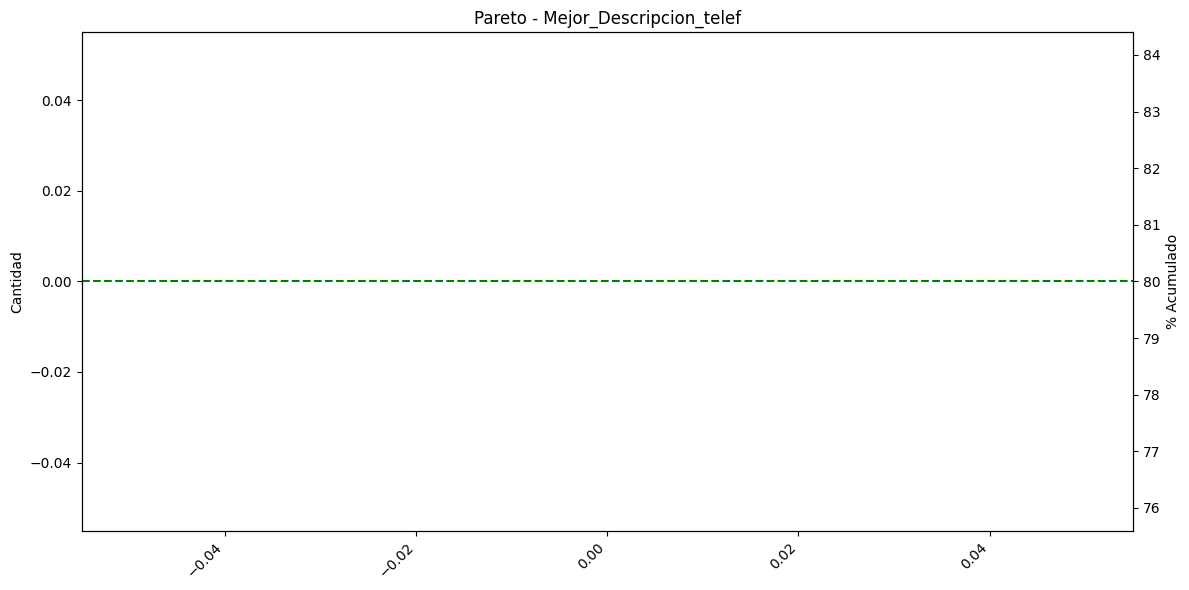

In [129]:

df_dni = df_filtrado.toPandas()
pareto_mejor_descripcion(df_dni,tipificaicon_telf)

In [48]:

exportar_lista(df_filtrado,'tc_cenco_202603301418.xlsx','linea_cencosud')

In [50]:
cantidad_leads=df_filtrado.count()

In [56]:
info_list=f"""
Se tienen {cantidad_leads} leads
Prioridad : {quintil}
maximo de intentos por num telef: {q_intentos_telef}
flg_ex_cliente :{flg_ex_cliente}
{segmento}
{first_name}

"""

print(info_list)


Se tienen 2814 leads
Prioridad : ['1', '2']
maximo de intentos por num telef: 40
flg_ex_cliente :['NUEVO']
['TC2', 'TC1']
['SEGMENTO BONUS', 'SEGMENTO EXCLUSIVO']




In [79]:
exportar_lista(df_filtrado,'tc_cencor_202603310847.xlsx','linea_cencosud')

['LLAMADA ELIMINADA POR ERROR EN RED (AUTO)', 'VOLVER A LLAMAR', 'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA', 'NO UTILIZA (TARJETAS - PRESTAMOS)', 'AUTODIAL NO RESPONDE (AUTO)', 'OFERTA DE TASA MUY ALTA', 'OFERTA DE LINEA MUY BAJA', 'NO DESEA PAGAR MEMBRESIA', 'NO SE CONCRETO LLAMADA (CASILLA DE VOZ - APAGADO)', 'VOLVER A LLAMAR (TERCERO RELACIONADO)', 'ZONA FUERA DE COBERTURA', 'NO VOLVER A LLAMAR NUNCA MAS', 'VOLVER A LLAMAR - call', 'TELEFONO OCUPADO / NO CONTESTAN', 'OCUPADO (AUTO)', 'NO SE ASIGNO RESULTADO A LA LLAMADA (AUTO)', 'NO DESEA –NO ESPECIFICA MOTIVO', 'TELEFONO EQUIVOCADO', 'NUMERO DESCONECTADO (AUTO)', 'MENSAJE EN CASILLA DE VOZ (AUTO)', 'CLIENTE FALLECIO', 'CLIENTE ACEPTA PRODUCTO', 'TELEFONO FUERA DE SERVICIO / NO EXISTE', 'DESEA IR A AGENCIA', 'CLIENTE DESEA OTRO PRODUCTO', 'AGENTE NO DISPONIBLE (AUTO)', None]


In [ ]:
import os

ruta_archivo = os.path.join(ruta_csv, 'ivr_202603271706.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

In [142]:

df_dni = df_filtrado.toPandas()


In [73]:
los pu pm los qu epodemos usar


SyntaxError: invalid syntax (2290498890.py, line 1)

In [12]:

nombre_archivo_xlsx='SAE_202603251722.xlsx'
columna_ref='linea_sae'
exportar_lista(df_filtrado,nombre_archivo_xlsx,columna_ref)


In [ ]:
fecha_mes_base='2026-03-01'
t_maestra='Base_Maestra_Cencosud_PPFF'
t_name_vigente='Base_Maestra_Cencosud_PPFF_vigente'
t_mumeros='tNumeroCenco_Sae'
cols_drop=[ 'FRESCURA_TARGET', 'REP1', 'REP2', 'REP3','FLAT2']


In [97]:
df_filtrado = df_filtrado.select(
    'vendor_lead_code', 'phone_number', 'first_name',
    'last_name', 'address1', 'address2', 'address3',
    'city', 'province', 'email', 'security_phrase', 'comments'
)
df_dni = df_filtrado.toPandas()

In [ ]:
import matplotlib.pyplot as plt

df_dni['email'].value_counts().plot(kind='bar')

plt.title('Top departamentos (email)')
plt.xlabel('Departamento')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()

In [8]:
df_list.select('retiro_01').filter(col('retiro_01')==0).count()

2266

In [13]:
# print([row['first_name'] for row in df_list.select('first_name').distinct().collect()])
# print([row['title'] for row in df_list.select('title').distinct().collect()])
# print([row['tip_prioridad'] for row in df_list.select('tip_prioridad').distinct().collect()])
# print([row['email'] for row in df_list.select('email').distinct().collect()])
# print([row['prioridada'] for row in df_list.select('prioridada').distinct().collect()])
print([row['mejor15_descripcion_telf' ] for row in df_list.select('mejor15_descripcion_telf').distinct().collect()])
# print(df_list.columns)


['PERSONA FALLECIDA', 'VOLVER A LLAMAR', 'LO VA A PENSAR', 'DESEA ELECTRO', 'NEGOCIO EN ZONA NO COBERTURADA', 'TITULAR CONTAGIADO CON COVID - 19', 'CREDITO CONCRETADO', 'MENSAJES CON TERCEROS - HIJOS', 'NO DESEA SER CONTACTADO / MANIFIESTA SU RECHAZO', 'NO NECESITA / NO DESEA', 'TELEFONO APAGADO', 'NUMERO EQUIVOCADO', 'ESTA ENDEUDADO', 'MENSAJES CON TERCEROS - ESPOSA', 'OTROS', 'NO CONTESTA ', 'TITULAR NO CALIFICA- GIRO RESTRINGIDO9', 'CLIENTE RECHAZADO', 'MENSAJES CON TERCEROS - OTROS', 'NO BRINDA CONSENTIMIENTO', 'CASA EN ZONA NO COBERTURADA', 'SI QUIERE', 'CLIENTE DE VIAJE', 'TELEFONO FUERA DE SERVICIO/SUSPENDIDO', 'CONFIRMAR CITA', 'INTERESES ELEVADOS', 'NUMERO NO EXISTE', 'TITULAR NO CALIFICA - DESEMPLEO', 'MENSAJES DE TEXTO', 'TONO OCUPADO', 'SOLICITA SER RETIRADO', 'IVR - NO CONFIRMA', 'MALA EXPERIENCIA (TDA/FNC)', 'DESEA MAS MONTO', 'NO QUIERE', None]


### CArga rapida

In [42]:
filename='LlistaVentas CREDICASH  2026.csv'
df_prueba_ch=cargar_archivo_csv(spark,filename,';',True)

filename='TARGET_202604_02.csv'
df_prueba_2=cargar_archivo_csv(spark,filename,';',True)

filename='TARGET_202604_01.csv'
df_prueba_1=cargar_archivo_csv(spark,filename,';',True)


In [43]:
df_prueba_1 = df_prueba_1.withColumn(
    "NUMERO_DOCUMENTO",
    F.right(
        F.concat(F.lit("00000000"), F.col("NUMERO_DOCUMENTO")),
        F.lit(8)
    )
)
df_prueba_2 = df_prueba_2.withColumn(
    "NUMERO_DOCUMENTO",
    F.right(
        F.concat(F.lit("00000000"), F.col("NUMERO_DOCUMENTO")),
        F.lit(8)
    )
)
df_prueba_ch = df_prueba_ch.withColumn(
    "NUMERO_DOCUMENTO",
    F.right(
        F.concat(F.lit("00000000"), F.col("NUMERO_DOCUMENTO")),
        F.lit(8)
    )
)

In [46]:
from pyspark.sql import functions as F

exprs = [
    F.count(F.when(F.col(c).isNotNull(), c)).alias(c)
    for c in df_prueba_2.columns
]

df_counts = df_prueba_2.agg(*exprs).collect()[0].asDict()

cols_con_data = [c for c, v in df_counts.items() if v > 0]

df_prueba_2 = df_prueba_2.select(cols_con_data)

In [29]:
df_prueba_1.select('CELULAR05').distinct().show(10)
# df_prueba_1.select('CELULAR01').distinct().show(10)

+---------+
|CELULAR05|
+---------+
|     NULL|
+---------+



In [50]:
from pyspark.sql import functions as F

df_prueba_ch = df_prueba_ch.withColumn(
    "CELULAR01",
    F.when(F.col("CELULAR01").rlike(r"^9\d{0,8}$"), F.col("CELULAR01"))
)
df_prueba_ch = df_prueba_ch.withColumn(
    "CELULAR02",
    F.when(F.col("CELULAR02").rlike(r"^9\d{0,8}$"), F.col("CELULAR02"))
)
df_prueba_ch = df_prueba_ch.withColumn(
    "CELULAR03",
    F.when(F.col("CELULAR03").rlike(r"^9\d{0,8}$"), F.col("CELULAR03"))
)



In [53]:
print(df_prueba_1.columns)
print(df_prueba_2.columns)
print(df_prueba_ch.columns)

['ID PROVEEDOR', 'NOMBRES', 'APELLIDO PATERNO', 'TIPO DE DOCUMENTO', 'NUMERO_DOCUMENTO', 'TASA(TEA)', 'TEA_DF', 'CELULAR01', 'CELULAR02', 'CELULAR03', 'RECENCIA', 'PERFIL', 'PRODUCTO', 'LINEA_DIN', 'ID RESULTADO GESTION', 'TCEA_NEW', 'TCEA_CUOTAS_DF', 'LIMACALLAO', 'FECHA_NACIMIENTO', 'PROVINCIA', 'L_BCP', 'L_BBVA', 'L_IBK', 'L_SCO', 'L_BIF', 'L_CITI', 'L_FIN', 'L_RIP', 'L_CMR', 'L_CRESCO', 'L_CEN', 'L_AZT', 'L_UNO', 'L_GNB', 'L_EFE', 'L_COM', 'L_NAC', 'EX_SOCIO', 'LINEA_ANT_EX_SOCIO', 'ULT_TASA_EX_SOCIO', 'PRIORIDAD', 'BENCH', 'FUENTE', 'SEGMENTACION']
['ID PROVEEDOR', 'NOMBRES', 'APELLIDO PATERNO', 'TIPO DE DOCUMENTO', 'NUMERO_DOCUMENTO', 'TASA(TEA)', 'TEA_DF', 'CELULAR01', 'CELULAR02', 'CELULAR03', 'RECENCIA', 'PERFIL', 'PRODUCTO', 'LINEA_DIN', 'ID RESULTADO GESTION', 'TCEA_NEW', 'TCEA_CUOTAS_DF', 'LIMACALLAO', 'FECHA_NACIMIENTO', 'PROVINCIA', 'L_BCP', 'L_BBVA', 'L_IBK', 'L_SCO', 'L_BIF', 'L_CITI', 'L_FIN', 'L_RIP', 'L_CMR', 'L_CRESCO', 'L_CEN', 'L_AZT', 'L_UNO', 'L_GNB', 'L_EFE', '

In [52]:
df_prueba_ch=df_prueba_ch.withColumnRenamed('SEGMENTO','SEGMENTACION')
df_prueba_2=df_prueba_2.withColumnRenamed('Segmentacion','SEGMENTACION')
df_prueba_2=df_prueba_2.withColumnRenamed('Prioridad','PRIORIDAD')
df_prueba_2=df_prueba_2.withColumnRenamed('Fuente','FUENTE')

In [54]:
window_spec = Window.partitionBy("NUMERO_DOCUMENTO").orderBy(F.col("SEGMENTACION").asc_nulls_last())
df_prueba_1 = df_prueba_1.withColumn("ref01", row_number().over(window_spec))
df_prueba_2 = df_prueba_2.withColumn("ref01", row_number().over(window_spec))
df_prueba_ch = df_prueba_ch.withColumn("ref01", row_number().over(window_spec))



In [57]:
df_prueba_1 = df_prueba_1.filter(F.col('NUMERO_DOCUMENTO').isNotNull())    
df_prueba_2 = df_prueba_2.filter(F.col('NUMERO_DOCUMENTO').isNotNull())    
df_prueba_ch = df_prueba_ch.filter(F.col('NUMERO_DOCUMENTO').isNotNull())    

 

In [ ]:
df_prueba_1 = df_prueba_1.filter(F.col('ref01')==1).drop('ref01')    
df_prueba_2 = df_prueba_2.filter(F.col('ref01')==1).drop('ref01')    
df_prueba_ch = df_prueba_ch.filter(F.col('ref01')==1).drop('ref01')    

 

In [58]:
overwrite_table_SQL(spark,df_prueba_1,f'se_borra_202604_01',server_kishin,user_kishin,pwd_kishin,'DANTALION')
overwrite_table_SQL(spark,df_prueba_2,f'se_borra_202604_02',server_kishin,user_kishin,pwd_kishin,'DANTALION')
overwrite_table_SQL(spark,df_prueba_ch,f'se_borra_202604_ch',server_kishin,user_kishin,pwd_kishin,'DANTALION')


In [8]:
spark.stop()

In [ ]:
from pyspark.sql import functions as F

df_prueba = df_prueba.withColumn(
    "CEL01",
    F.when(F.col("CELULAR1").rlike(r"^9\d{0,8}$"), F.col("CELULAR1"))
)
df_prueba = df_prueba.withColumn(
    "CEL02",
    F.when(F.col("CELULAR2").rlike(r"^9\d{0,8}$"), F.col("CELULAR2"))
)
df_prueba = df_prueba.withColumn(
    "CEL02",
    F.when(F.col("CELULAR3").rlike(r"^9\d{0,8}$"), F.col("CELULAR3"))
)



In [ ]:
df_prueba_1=df_prueba_1.filter(F.col('NUMERO_DOCUMENTO').isNotNull())
df_prueba_2=df_prueba_2.filter(F.col('NUMERO_DOCUMENTO').isNotNull())
df_prueba_ch=df_prueba_ch.filter(F.col('NUMERO_DOCUMENTO').isNotNull())



In [3]:
overwrite_table_SQL(spark,df_prueba_1,f'borrar_TARGET_202604_01',server_kishin,user_kishin,pwd_kishin,'DANTALION')
overwrite_table_SQL(spark,df_prueba_2,f'borrar_TARGET_202604_02',server_kishin,user_kishin,pwd_kishin,'DANTALION')
overwrite_table_SQL(spark,df_prueba_ch,f'borrar_TARGET_202604_ch',server_kishin,user_kishin,pwd_kishin,'DANTALION')


In [4]:
import pyodbc


In [5]:
def ejecutar_sql(server, db_name, user, pwd, query):
    conn = pyodbc.connect(
        f"DRIVER={{ODBC Driver 17 for SQL Server}};"
        f"SERVER={server};"
        f"DATABASE={db_name};"
        f"UID={user};"
        f"PWD={pwd};"
        f"TrustServerCertificate=yes;"
    )

    cursor = conn.cursor()
    cursor.execute(query)
    conn.commit()

    print("Filas afectadas:", cursor.rowcount)

    cursor.close()
    conn.close()

In [ ]:
query = """
update a

inner join CRONOX.dbo.borrar_TARGET_202604_01 a
set cabecera_carga='prueba'
"""
# ejecutar_sql(server_sa, db_sa, user_sa, pwd_sa, query)

In [ ]:
query = """
update CRONOX.dbo.borrar_df_alfin_01
set cabecera_carga='prueba'
"""
ejecutar_sql(server_sa, db_sa, user_sa, pwd_sa, query)

Filas afectadas: 80321


In [7]:
query_drop = """
DROP TABLE IF EXISTS CRONOX.dbo.borrar_df_alfin_01
"""

ejecutar_sql(server_sa, db_sa, user_sa, pwd_sa, query_drop)

Filas afectadas: -1


In [1]:
import sys 
sys.path.append('C:/Users/DATA/Documents/datos/01_script/inicio/funciones')
from funciones import *
from funciones_spark import *
from variables_inicio import *
from utils_sql import *

In [6]:
spark.stop()

In [11]:
# overwrite_table_SQL(spark,df_prueba_ppd_plus,f'boorarrrrrr__PLUS',server_kishin,user_kishin,pwd_kishin,'DANTALION')
overwrite_table_SQL(spark,df_prueba_ppd,f'boorarrrrrr__PPD2S',server_kishin,user_kishin,pwd_kishin,'DANTALION')


## actualizar tnumero | vigente en tres servidores 

In [6]:
spark.stop()

In [5]:
exec_query_sql(server_kishin, db_kishin, user_kishin, pwd_kishin, "tNumeros_Diners", "SP tNumeros diners")
exec_query_sql(server_zeus, "ODIN", user_zeus, pwd_zeus, "EXEC Sp_Actualizar_Diners", "SP actualizar diners Zeus")
exec_query_sql(server_sa, "ODIN", user_sa, pwd_sa, "EXEC Sp_Actualizar_Diners", "SP actualizar diners SA")

SP tNumeros diners | realizado | duración: 7.78 seg
SP actualizar diners Zeus | realizado | duración: 13.61 seg
SP actualizar diners SA | realizado | duración: 2.72 seg


In [21]:
exec_query_sql(server_kishin, db_kishin, user_kishin, pwd_kishin, "tNumeros_Diners_Tc", "SP tNumeros diners_tc")
exec_query_sql(server_zeus, "ODIN", user_zeus, pwd_zeus, "EXEC Sp_Actualizar_Diners_Tc", "SP actualizar diners_tc Zeus")
exec_query_sql(server_sa, "ODIN", user_sa, pwd_sa, "EXEC Sp_Actualizar_Diners_Tc", "SP actualizar diners_tc SA")

SP tNumeros diners_tc | realizado | duración: 46.73 seg
SP actualizar diners_tc Zeus | realizado | duración: 13.91 seg
SP actualizar diners_tc SA | realizado | duración: 2.37 seg


In [7]:
ventas del 1 al 7 

SyntaxError: invalid syntax (3762695691.py, line 1)

In [ ]:
archivo de planeamiento 

In [ ]:
exec_query_sql(server_zeus, "MAEBA", user_zeus, pwd_zeus, "EXEC MAEBA.ADM_OBJ_TG.spFunnelDiner", "SP actualizar funnel Zeus")


SP actualizar funnel Zeus | realizado | duración: 16.59 seg


In [7]:
# exec_query_sql(server_kishin, db_kishin, user_kishin, pwd_kishin, "tNumeros_Diners_Tc", "SP tNumeros diners_tc")
exec_query_sql(server_zeus, "ODIN", user_zeus, pwd_zeus, "EXEC Sp_Actualizar_Diners", "SP actualizar diners_tc Zeus")
exec_query_sql(server_sa, "ODIN", user_sa, pwd_sa, "EXEC Sp_Actualizar_Diners", "SP actualizar diners_tc SA")

SP actualizar diners_tc Zeus | realizado | duración: 4.02 seg
SP actualizar diners_tc SA | realizado | duración: 2.13 seg


In [12]:
exec_query_sql(server_sa, "CRONOX", user_sa, pwd_sa, "EXEC SP_Generador_DINERS_TC", "SP actualizar diners_prestamo SA")
exec_query_sql(server_sa, "CRONOX", user_sa, pwd_sa, "EXEC SP_Generador_DINERS", "SP actualizar diners_tc SA")

SP actualizar diners_prestamo SA | realizado | duración: 10.36 seg
SP actualizar diners_tc SA | realizado | duración: 2.21 seg
